In [26]:
# ==============================================================
# 🧠 Sleep Health and Lifestyle Analysis - Linear Regression
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [27]:
# ==============================================================
# 1️⃣ Load Dataset
# ==============================================================
data = pd.read_csv(r'C:\mechine_learning\Sleep_health_and_lifestyle_dataset.csv')



In [28]:
data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [29]:
# ==============================================================
# 2️⃣ Data Cleaning and Preprocessing
# ==============================================================
# Split 'Blood Pressure' into two columns
data[['Systolic BP', 'Diastolic BP']] = data['Blood Pressure'].str.split('/', expand=True).astype(int)
data.drop('Blood Pressure', axis=1, inplace=True)

# One-hot encode categorical columns
data = pd.get_dummies(data, columns=['Gender', 'BMI Category', 'Sleep Disorder', 'Occupation'], drop_first=True)

# Scale numerical columns
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                  'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

In [30]:
# ==============================================================
# 3️⃣ Train-Test Split
# ==============================================================
X = data.drop(['Quality of Sleep', 'Person ID'], axis=1)
y = data['Quality of Sleep']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [31]:
# ==============================================================
# 4️⃣ Train Model and Evaluate
# ==============================================================
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Model trained successfully!")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

✅ Model trained successfully!
Mean Squared Error: 0.03603344988977646
R² Score: 0.9658713674991259
Coefficients: [ 0.39664755  0.18553349 -0.01073167 -0.5330727  -0.1072739   0.0442576
  0.01042635 -0.10575613  0.46171849 -0.09086172  0.04584471 -0.42697167
  0.09426091 -0.45977449 -0.53245781 -0.30388825 -0.19868725 -0.12885789
 -1.39018956 -0.76188014 -0.43868906 -0.06550149 -0.47080292]
Intercept: 0.29211730939741437


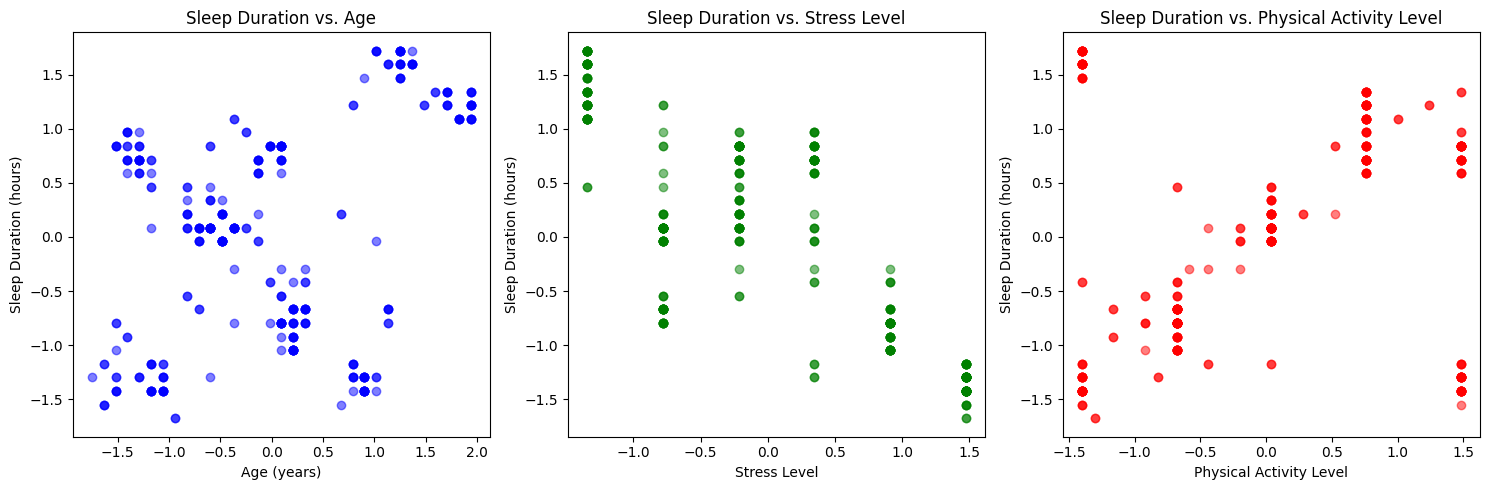

In [32]:
# ==============================================================
# 5️⃣ Visualization: Correlation Analysis
# ==============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(data['Age'], data['Sleep Duration'], color='blue', alpha=0.5)
axes[0].set_title('Sleep Duration vs. Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Sleep Duration (hours)')

axes[1].scatter(data['Stress Level'], data['Sleep Duration'], color='green', alpha=0.5)
axes[1].set_title('Sleep Duration vs. Stress Level')
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Sleep Duration (hours)')

axes[2].scatter(data['Physical Activity Level'], data['Sleep Duration'], color='red', alpha=0.5)
axes[2].set_title('Sleep Duration vs. Physical Activity Level')
axes[2].set_xlabel('Physical Activity Level')
axes[2].set_ylabel('Sleep Duration (hours)')

plt.tight_layout()
plt.show()

In [33]:
# ==============================================================
# 6️⃣ Build Simple Sleep Duration Predictor
# ==============================================================
X_simple = data[['Age', 'Stress Level', 'Physical Activity Level']]
y_simple = data['Sleep Duration']

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_simple)
y_scaled = scaler_y.fit_transform(y_simple.values.reshape(-1, 1))


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
# Predict new data
new_data = pd.DataFrame({'Age': [70], 'Stress Level': [5], 'Physical Activity Level': [30]})
new_scaled = scaler_X.transform(new_data)
pred_scaled = model.predict(new_scaled)
pred_original = scaler_y.inverse_transform(pred_scaled)

print(f"🕒 Predicted Sleep Duration: {pred_original[0][0]:.2f} hours")



🕒 Predicted Sleep Duration: -0.43 hours


🕒 Predicted Sleep Duration: -0.43 hours


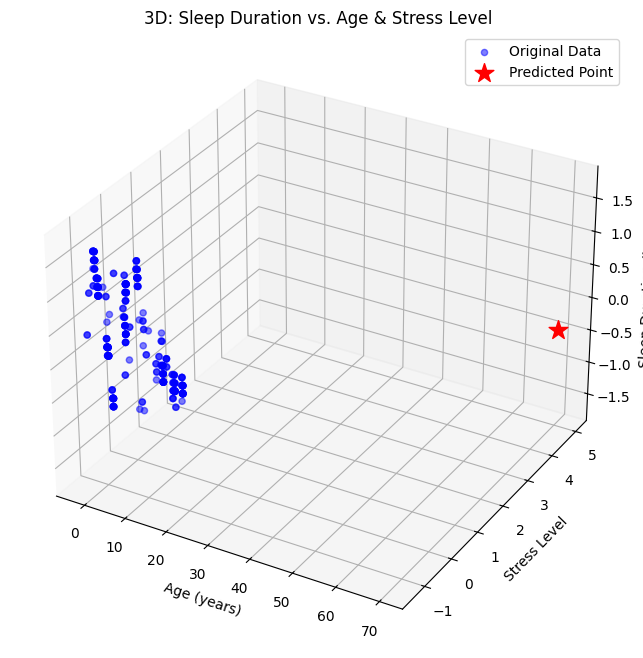

In [36]:
# ==============================================================
# 7️⃣ 3D Visualization
# ==============================================================
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['Age'], data['Stress Level'], data['Sleep Duration'], c='blue', alpha=0.5, label='Original Data')
ax.scatter(new_data['Age'], new_data['Stress Level'], pred_original[0][0], c='red', marker='*', s=200, label='Predicted Point')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Stress Level')
ax.set_zlabel('Sleep Duration (hours)')
ax.set_title('3D: Sleep Duration vs. Age & Stress Level')
ax.legend()# Predict new data
new_data = pd.DataFrame({'Age': [70], 'Stress Level': [5], 'Physical Activity Level': [30]})
new_scaled = scaler_X.transform(new_data)
pred_scaled = model.predict(new_scaled)
pred_original = scaler_y.inverse_transform(pred_scaled)

print(f"🕒 Predicted Sleep Duration: {pred_original[0][0]:.2f} hours")